In [2]:
import os
import h5py
import torch
from torch.utils.data import Dataset
import numpy as np
import torch
from torch import optim
import torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from numpy import random
import cv2
from numpy import identity

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
print(os.listdir('/content/drive/MyDrive'))

['General presentation.gslides', 'SLIDE PRESENTATION:.gdoc', 'Photos', 'Em2.1bexbct.gdoc', 'amankhanal.mp4', 'filter3.1bei.gdoc', 'landslide4sense.zip', 'Colab Notebooks', 'best_unet_model.pth', 'best_resunet_gat_model.pth']


In [4]:
!unzip -q "/content/drive/MyDrive/landslide4sense.zip" -d /content/

In [1]:
# =============================================================================
# HELPER FUNCTION: Compute Topographic Features from DEM
# =============================================================================
# This is a plain Python function — no PyTorch needed here.
# It takes numpy arrays as input and returns numpy arrays as output.


def compute_topographical_features(dem, slope, res=10.0):
    """ Compute northness, eastness, profile curvature"""

    dem_padded = np.pad(dem, pad_width=1, mode="edge")

    dy, dx = np.gradient(dem_padded, res)

    d2y, _ = np.gradient(dy, res)
    _, d2x = np.gradient(dx, res)

    # removing the padding added in the beginning
    dx = dx[1:-1, 1:-1]
    dy = dy[1:-1, 1:-1]
    d2x = d2x[1:-1, 1:-1]
    d2y = d2y[1:-1, 1:-1]

    aspect = np.arctan2(-dy, dx)
    northness = np.cos(aspect)
    eastness = np.sin(aspect)

    curvature = d2x + d2y

    return northness, eastness, curvature


def compute_normalization(img_dir, file_ids): 
    """ Compute the mean and the standard deviation from the training set only. Protected against NaN vlaues. """
    N_CHANNELS = 17
    channel_sum = np.zeros(N_CHANNELS, dtype=np.float64)
    channel_squared_sum = np.zeros(N_CHANNELS, dtype=np.float64)
    pixel_count = 0
    eps = 1e-6
    
    for file_id in file_ids:
        img_path = os.path.join(img_dir, f"image_{file_id}.h5")
        if not os.path.exists(img_path):
            continue  # Skip if the file does not exist

        with h5py.File(img_path, "r") as f:
            raw_image = f["img"][:]
            
        blue  = raw_image[:, :, 1].astype(np.float32)
        green = raw_image[:, :, 2].astype(np.float32)
        red   = raw_image[:, :, 3].astype(np.float32)
        b5    = raw_image[:, :, 4].astype(np.float32)
        b6    = raw_image[:, :, 5].astype(np.float32)
        b7    = raw_image[:, :, 6].astype(np.float32)
        nir   = raw_image[:, :, 7].astype(np.float32)
        
        # b8a   = raw_image[:, :, 8].astype(np.float32)
        swir1 = raw_image[:, :, 10].astype(np.float32)
        swir2 = raw_image[:, :, 11].astype(np.float32)
        slope = raw_image[:, :, 12].astype(np.float32)
        dem   = raw_image[:, :, 13].astype(np.float32)
        
        northness, eastness, curvature = compute_topographical_features(dem, slope)
        
        ndvi = (nir - red) / (nir + red + eps)
        bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + eps)
        ndwi = (green - nir) / (green + nir + eps)
        
        image_17ch = np.stack(
            [dem, slope, northness, eastness, curvature, blue, green, red, nir, b5, b6, b7, swir1, swir2, ndvi, bsi, ndwi], axis=-1
        )  # final 17 channel raster
        
        image_17ch = np.nan_to_num(image_17ch, nan=0.0)  # Replace NaN values with 0.0
        
        h, w, _ = image_17ch.shape
        
        channel_sum += np.sum(image_17ch, axis=(0, 1))
        channel_squared_sum += np.sum(image_17ch ** 2, axis=(0, 1))
        pixel_count += h * w

    means = channel_sum / pixel_count
    stds = np.sqrt((channel_squared_sum / pixel_count) - (means ** 2))
    
    # At the end, it spits out two lists. Each list has exactly 17numbers in it.

    # self.means = [mean_ch1, mean_ch2, mean_ch3, ..., mean_ch17]

    # self.stds = [std_ch1, std_ch2, std_ch3, ..., std_ch17]
        

    return means.astype(np.float32), stds.astype(np.float32)

def train_transform(means, stds):
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),

        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=(-0.1, 0.1),
            rotate_limit=10,
            border_mode=cv2.BORDER_REFLECT,
            p=0.5
        ),
        # Applying normalization here
        # it does img = (img - mean * max_pixel_value) / (std * max_pixel_value) inder the hood
        A.Normalize(mean=list(means), std=list(stds), max_pixel_value=1.0),

        ToTensorV2()
    ])


def val_transform(means, stds):
    return A.Compose([
        A.Normalize(mean=list(means), std=list(stds), max_pixel_value=1.0),
        ToTensorV2()
    ])


# =============================================================================
# PYTORCH DATASET CLASS: LandslideDataset
# =============================================================================
# In TensorFlow you often loaded data with tf.data.Dataset or keras utilities.
# In PyTorch, the standard way is to define a Dataset class with these 3 methods:
#
#   __init__  → runs once when you create the dataset object (setup/configuration)
#   __len__   → tells PyTorch how many samples exist (used by DataLoader)
#   __getitem__ → loads and returns ONE sample by index (called repeatedly during training)
#
# PyTorch's DataLoader will call __getitem__ automatically in batches.


class LandslideDataset(Dataset):

    def __init__(self, img_dir, mask_dir=None, transform=None, file_ids = None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        if file_ids is not None:
            self.file_ids = file_ids
        else:
            self.file_ids = sorted(
                [
                    int(f.split("_")[1].split(".")[0])
                    for f in os.listdir(img_dir)
                    if f.endswith(".h5")
                ]
            )

    def __len__(self):
        return len(self.file_ids)

    def __getitem__(self, idx):
        file_id = self.file_ids[idx]
        img_name = f"image_{file_id}.h5"
        mask_name = f"mask_{file_id}.h5"

        with h5py.File(os.path.join(self.img_dir, img_name), "r") as f:
            raw_image = f["img"][:]

        if self.mask_dir is not None:
            with h5py.File(os.path.join(self.mask_dir, mask_name), "r") as f:
                mask = f["mask"][:]
        else:
            mask = np.zeros((128, 128), dtype=np.int64)

        eps = 1e-6

        blue = raw_image[:, :, 1]
        green = raw_image[:, :, 2]
        red = raw_image[:, :, 3]
        b5 = raw_image[:, :, 4]
        b6 = raw_image[:, :, 5]
        b7 = raw_image[:, :, 6]
        nir = raw_image[:, :, 7]
        # b8a = raw_image[:, :, 8]
        swir1 = raw_image[:, :, 10]
        swir2 = raw_image[:, :, 11]
        
        # Terrain features
        slope = raw_image[:, :, 12]
        dem = raw_image[:, :, 13]

        northness, eastness, curvature = compute_topographical_features(dem, slope)

        ndvi = (nir - red) / (nir + red + eps)

        bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + eps)

        ndwi = (green - nir) / (green + nir + eps)

        # axis=-1 means the new axis is added at the END → shape: (128, 128, 17)
        image_17ch = np.stack(
            [dem, slope, northness, eastness, curvature, blue, green, red, nir, b5, b6, b7, swir1, swir2, ndvi, bsi, ndwi], axis=-1
        ).astype(np.float32)  # Final shape: (128, 128, 17)

        image_17ch = np.nan_to_num(image_17ch, nan=0.0, posinf=0.0, neginf=0.0)

    # this will do the normalization, rotation and convert to the tensors
        if self.transform:

            augmented = self.transform(image=image_17ch, mask=mask)
            image = augmented['image'].float()
            mask = augmented['mask'].long()
        else:
            image_17ch = image_17ch.transpose((2, 0, 1))  # (C, H, W)

            image = torch.from_numpy(image_17ch).float()
            mask = torch.from_numpy(mask).long()
            

        return image, mask


NameError: name 'Dataset' is not defined

In [19]:
# # ----- Part-1: U-Net Architecture -----


# class ConvBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.block = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),  ## out_channels means filters in keras, and keras figures out the in_channel itself
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#         )

#     def forward(self, x):
#         return self.block(x)


# # Encoder Block: ConvBlock + MaxPool


# class EncoderBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.conv = ConvBlock(in_channels, out_channels)
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

#     def forward(self, x):
#         features = self.conv(x)
#         pooled = self.pool(features)
#         return features, pooled
#         # return both:
#         # features -> will be passed accross via skip connection to decoder
#         # pooled -> goes down to the next encoder block


# # Decoder Block: Upsampe + Concatenate skip + convBlock
# class DecoderBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.upsample = nn.ConvTranspose2d(
#             in_channels, out_channels, kernel_size=2, stride=2
#         )
#         # convTransposed2d doubles the spatial size: (64, 64) → (128, 128)

#         self.conv = ConvBlock(out_channels * 2, out_channels)

#     def forward(self, x, skip):
#         x = self.upsample(x)
#         x = torch.cat([x, skip], dim=1)  # concatenate along channel dimension
#         x = self.conv(x)
#         return x


# # --- Full U-Net Model ---
# class UNet(nn.Module):
#     def __init__(self, in_channels=8, num_classes=2):
#         """
#         in_chennels : number of input channels - 8 for our dataset
#         num_classes : 2 for binary segmentation (landslide / no-landslide)
#         """

#         super().__init__()

#         # Encoder ( Contracting Path)

#         self.enc1 = EncoderBlock(in_channels, 64)  # 8 → 64
#         self.enc2 = EncoderBlock(64, 128)  # 64 → 128
#         self.enc3 = EncoderBlock(128, 256)  # 128 → 256
#         self.enc4 = EncoderBlock(256, 512)  # 256 → 512

#         # Bottleneck (deepest point - no pooling)

#         self.bottleneck = ConvBlock(512, 1024)  # 512 → 1024

#         # Decoder (Expanding Path)

#         self.dec4 = DecoderBlock(1024, 512)  # 1024 → 512
#         self.dec3 = DecoderBlock(512, 256)  # 512 → 256
#         self.dec2 = DecoderBlock(256, 128)  # 256 → 128
#         self.dec1 = DecoderBlock(128, 64)  # 128 → 64

#         # --- Final Output Layer ---
#         self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)
#         # kernel size=1 -> 1x1 convolution, just maps 64 channels -> num_classes

#     def forward(self, x):
#         # ---Encoder ---
#         skip1, x = self.enc1(x)  # skip for dec1, x: goes to enc2
#         skip2, x = self.enc2(x)
#         skip3, x = self.enc3(x)
#         skip4, x = self.enc4(x)  # skip for dec4, x: goes to bottleneck

#         # --- Bottleneck ---
#         x = self.bottleneck(x)

#         # --- Decoder ---
#         x = self.dec4(x, skip4)  # input from bottleneck, skip from enc4
#         x = self.dec3(x, skip3)
#         x = self.dec2(x, skip2)
#         x = self.dec1(x, skip1)  # input from dec2, skip from enc1

#         # --- Final Output ---
#         return self.output_conv(x)  # shape: (Batch, 2, 128, 128)

In [20]:
#     --------------ResUNet Model----------------------

# class ResidualBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
        
#         # First convolution
#         self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
#         self.bn1 = nn.BatchNorm2d(out_channels)
#         self.relu = nn.ReLU(inplace=True)
        
#         # Second convolution
#         self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
#         self.bn2 = nn.BatchNorm2d(out_channels)
        
#         # Shortcut connection
#         # if the input and the output dont match, we need a 1x1 convolution,
#         # to project the correct input before adding.
#         self.shortcut = nn.Sequential()
#         if in_channels != out_channels:
#             self.shortcut = nn.Sequential(
#                 nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
#                 nn.BatchNorm2d(out_channels)
#             )
            

#     def forward(self, x):
#         identity = self.shortcut(x)
        
#         out = self.conv1(x)
#         out = self.bn1(out)
#         out = self.relu(out)
        
#         out = self.conv2(out)
#         out = self.bn2(out)
        
#         out += identity
#         out = self.relu(out)
        
#         return out


# # ---- Encoder Block ---- #

# class EncoderBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.conv = ResidualBlock(in_channels, out_channels)
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

#     def forward(self, x):
#         features = self.conv(x)
#         pooled = self.pool(features)
#         return features, pooled

# # ---- Decoder Block ---- #

# class DecoderBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.upsample = nn.ConvTranspose2d(
#             in_channels, out_channels, kernel_size=2, stride=2
#         )

#         self.conv = ResidualBlock(out_channels * 2, out_channels)

#     def forward(self, x , skip):
#         upsampled = self.upsample(x)
#         cat = torch.cat([upsampled, skip], dim=1)
#         x = self.conv(cat)
#         return x
    
# class ResUNet(nn.Module):
#     def __init__(self, in_channels=17, num_classes=2):
#         super().__init__()

#         # --Encoding Phase -- 

#         self.enc1 = EncoderBlock(in_channels, 64)
#         self.enc2 = EncoderBlock(64, 128)
#         self.enc3 = EncoderBlock(128, 256)
#         self.enc4 = EncoderBlock(256, 512)

#         # --Bottleneck (deepest point - no pooling here)

#         self.bottleneck = ResidualBlock(512, 1024)

#         # --Decoding Phase --

#         self.dec4 = DecoderBlock(1024, 512)
#         self.dec3 = DecoderBlock(512, 256)
#         self.dec2 = DecoderBlock(256, 128)
#         self.dec1 = DecoderBlock(128, 64)

#         # -- Final Outout Layer -- 
#         self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)

#     def forward(self, x):
#             # ---Encoder---
#         skip1, x = self.enc1(x)
#         skip2, x = self.enc2(x)
#         skip3, x = self.enc3(x)
#         skip4, x = self.enc4(x)

#         # ---Bottleneck---
#         x = self.bottleneck(x)

#         #---Decoder---
#         x = self.dec4(x, skip4)
#         x = self.dec3(x, skip3)
#         x = self.dec2(x, skip2)
#         x = self.dec1(x, skip1)

#         # Final output

#         return self.output_conv(x)

In [21]:
# # ---------FUlly Connected Graph Attention Network (GAT) Layer ---------

# import torch.nn.functional as F

# class GATLayer(nn.Module):
#     def __init__(self, in_dim, out_dim, num_heads=4, dropout=0.1, concat=True):
#         super().__init__()
#         self.out_dim = out_dim
#         self.num_heads = num_heads
#         self.concat = concat
        
#         self.W = nn.Linear(in_dim, out_dim * num_heads, bias=False)     
        
#         self.a_src = nn.Parameter(torch.empty(size=(num_heads, out_dim)))
#         self.a_dst = nn.Parameter(torch.empty(size=(num_heads, out_dim)))
#         nn.init.xavier_uniform_(self.a_src)
#         nn.init.xavier_uniform_(self.a_dst)
        
#         self.leakyrelu = nn.LeakyReLU(0.2)
#         self.dropout = nn.Dropout(dropout)
    
#     def forward(self, x, adj=None):
#         B, N, _ = x.shape  # Batch size, Number of nodes, Feature dimension
#         H, D = self.num_heads, self.out_dim
        
#         # step 1: project every node, split into heads -> ( B, N, H, D)
#         Wh = self.W(x).view(B, N, H, D)
        
#         # step 2: compute attention logits e_ij for EvERY pair (i, j), per head, at once.
#         # src_scores = (wh * self.a_scr).sum(dim=-1) # (B, N, H)
#         # dst_scores = (Wh * self.a_dst).sum(dim=-1)  # (B, N, H)
#         src_scores = (Wh * self.a_src).sum(dim=-1)
#         dst_scores = (Wh * self.a_dst).sum(dim=-1)
        
#         e = src_scores.unsqueeze(2) + dst_scores.unsqueeze(1)  # (B, N, N, H)
#         e = self.leakyrelu(e)
        
#         # step 3: normalize into proper attention weight (softmax over neighbors j,
#         # for each destination node i)- every node's incomming weights sum to 1 
#         alpha = torch.softmax(e, dim=2) # (B, N, N, H)
#         alpha = self.dropout(alpha)
        
#         # step 4: weighted aggregation - out_i = sum_j(alpha_ij * Wh_j)
#         out = torch.einsum('bijh,bjhd->bihd', alpha, Wh)  # (B, N, H, D)
        
#         if self.concat:
#             out = out.reshape(B, N, H * D)  # (B, N, H*D)
#         else:
#             out = out.mean(dim=2)  # (B, N, D)
#         return out
    
    
# class SpatialGATBlock(nn.Module):
#     def __init__(self, channels, num_heads=4, num_layers=2, dropout=0.1):
#         super().__init__()
#         head_dim = channels // num_heads
#         assert head_dim * num_heads == channels, "channels must be divisible by num_heads"
        
#         self.layers = nn.ModuleList([
#             GATLayer(channels, head_dim, num_heads=num_heads, dropout=dropout, concat=True)
#             for _ in range(num_layers)
#         ])  
#         self.norm = nn.LayerNorm(channels)
        
#     def forward(self, x, adj=None):
#         B, C, H, W = x.shape
#         N = H * W
        
#         # (B, C, H, W) -> (B, N, C): one row per spatial location = one graph node
#         nodes = x.flatten(2).transpose(1, 2)  # (B, N, C)
        
#         h = nodes
#         for layer in self.layers:
#             h = layer(h, adj=adj)
#             h = F.elu(h)        
            
#         h = self.norm(nodes + h)
#         out = h.transpose(1, 2).reshape(B, C, H, W) 
#         return out
    


# class ResidualBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
        
#         # First convolution
#         self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
#         self.bn1 = nn.BatchNorm2d(out_channels)
#         self.relu = nn.ReLU(inplace=True)
        
#         # Second convolution
#         self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
#         self.bn2 = nn.BatchNorm2d(out_channels)
        
#         # Shortcut connection
#         # if the input and the output dont match, we need a 1x1 convolution,
#         # to project the correct input before adding.
#         self.shortcut = nn.Sequential()
#         if in_channels != out_channels:
#             self.shortcut = nn.Sequential(
#                 nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
#                 nn.BatchNorm2d(out_channels)
#             )
            

#     def forward(self, x):
#         identity = self.shortcut(x)
        
#         out = self.conv1(x); out = self.bn1(out); out = self.relu(out)
        
#         out = self.conv2(out); out = self.bn2(out)
        
#         out += identity
#         out = self.relu(out)
        
#         return out


# # ---- Encoder Block ---- #

# class EncoderBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.conv = ResidualBlock(in_channels, out_channels)
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

#     def forward(self, x):
#         features = self.conv(x)
#         pooled = self.pool(features)
#         return features, pooled

# # ---- Decoder Block ---- #

# class DecoderBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()
#         self.upsample = nn.ConvTranspose2d(
#             in_channels, out_channels, kernel_size=2, stride=2
#         )

#         self.conv = ResidualBlock(out_channels * 2, out_channels)

#     def forward(self, x , skip):
#         upsampled = self.upsample(x)
#         cat = torch.cat([upsampled, skip], dim=1)
#         x = self.conv(cat)
#         return x
    
# class ResUNetGAT(nn.Module):
#     def __init__(self, in_channels=17, num_classes=2, gat_heads=4, gat_layers=2):
#         super().__init__()

#         # --Encoding Phase -- 

#         self.enc1 = EncoderBlock(in_channels, 64)
#         self.enc2 = EncoderBlock(64, 128)
#         self.enc3 = EncoderBlock(128, 256)
#         self.enc4 = EncoderBlock(256, 512)

#         # --Bottleneck (deepest point - no pooling here)

#         self.bottleneck = ResidualBlock(512, 1024)
        
#         # --GAT Block-- global, non-local reasoning over the 8x8 = 64 bottleneck
#         self.gat_block = SpatialGATBlock(channels=1024, num_heads=gat_heads, num_layers=gat_layers)

#         # --Decoding Phase --

#         self.dec4 = DecoderBlock(1024, 512)
#         self.dec3 = DecoderBlock(512, 256)
#         self.dec2 = DecoderBlock(256, 128)
#         self.dec1 = DecoderBlock(128, 64)

#         # -- Final Outout Layer -- 
#         self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)

#     def forward(self, x):
#             # ---Encoder---
#         skip1, x = self.enc1(x)
#         skip2, x = self.enc2(x)
#         skip3, x = self.enc3(x)
#         skip4, x = self.enc4(x)

#         # ---Bottleneck + GAT---
#         x = self.bottleneck(x)
#         x = self.gat_block(x)      

#         #---Decoder---
#         x = self.dec4(x, skip4)
#         x = self.dec3(x, skip3)
#         x = self.dec2(x, skip2)
#         x = self.dec1(x, skip1)

#         # Final output

#         return self.output_conv(x)
        

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =============================================================================
# PART 3: GRAPH ATTENTION NETWORK (GAT) BOTTLENECK
# =============================================================================
# BACKGROUND CONTEXT — what a GAT actually is:
#
# A CNN convolution aggregates information from a small, FIXED neighborhood
# (e.g. a 3x3 window) using the SAME learned weights everywhere in the image.
# It has no way to say "this pixel is irrelevant to me" or "that pixel, way
# over there, actually matters a lot" — every neighbor gets the same fixed
# kernel treatment regardless of what's actually in the image.
#
# A Graph Neural Network (GNN) generalizes "convolution" to work over an
# arbitrary graph: a set of nodes, each with a feature vector, connected by
# edges. A GNN layer updates every node's features by aggregating (some
# combination of) its neighbors' features — this is called "message passing".
#
#   - Graph Convolutional Network (GCN): aggregates neighbors with weights
#     fixed by the graph structure alone (basically a normalized average).
#     Every neighbor is treated as equally important.
#
#   - Graph ATTENTION Network (GAT, Velickovic et al. 2018): learns, for
#     every edge (i, j), an attention weight alpha_ij that depends on BOTH
#     node i's and node j's actual features. So instead of "average my
#     neighbors", it's "let me learn how much to listen to each neighbor,
#     based on what's actually in their features right now."
#
#     e_ij       = LeakyReLU( a_src . (W h_i) + a_dst . (W h_j) )   <- raw score
#     alpha_ij   = softmax_j( e_ij )                                <- normalize per node i
#     h_i_new    = sum_j ( alpha_ij * (W h_j) )                     <- weighted aggregation
#
#     This is repeated with several independent "heads" (multi-head
#     attention, exactly like a Transformer) and the results are concatenated
#     — different heads can learn to attend to different kinds of
#     relationships.
#
# WHY THIS FITS AT THE RESUNET BOTTLENECK:
# Your bottleneck feature map is (Batch, 1024, 8, 8) for 128x128 input patches
# (128 -> 64 -> 32 -> 16 -> 8 after 4 pooling stages). That's only 8*8 = 64
# spatial locations. We treat each of those 64 locations as one graph "node"
# with a 1024-dim feature vector, and let every node attend to every other
# node (a fully-connected graph — cheap and simple at N=64: only 64*64=4096
# pairs per head, trivial compute).
#
# This gives the model genuine GLOBAL reasoning that convolutions structurally
# cannot provide, even at the bottleneck: a landslide signature on one side of
# a ridge can directly inform what the model predicts on the other side, or
# a scar downslope can be linked to the terrain that fed it, regardless of
# raw pixel distance. This bottleneck placement (replacing/augmenting the
# deepest conv block with GAT layers) is the standard way this has been done
# in published CNN+GAT segmentation hybrids — the same pattern published
# GAT-based landslide segmentation work (object/graph-based landslide models)
# and general "GNN at the U-Net bottleneck" architectures both use.
# =============================================================================


def build_grid_adjacency(H, W, connectivity=8, self_loops=True):
    """
    Builds a spatially-local adjacency matrix: node i is only connected to its
    immediate spatial neighbours (8-connectivity by default: up/down/left/right
    + diagonals; use connectivity=4 for just up/down/left/right). By default,
    each node is also connected to itself, matching the standard GAT setup.

    This matters when graph_type="local": instead of a node having to learn,
    across a nearly-empty-of-signal 64-node graph, which of 63 other nodes to
    ignore, it starts with a strong structural prior — "your neighbours are
    the locations physically next to you" — and only has to learn HOW MUCH to
    weight each of those ~8, not WHICH ones might matter out of 64. Given how
    sparse landslide-positive pixels are in this dataset, that's a much easier
    thing to learn well from limited data than dense attention is.
    """
    N = H * W
    adj = torch.zeros(N, N)
    for i in range(H):
        for j in range(W):
            idx = i * W + j
            for di in (-1, 0, 1):
                for dj in (-1, 0, 1):
                    if di == 0 and dj == 0:
                        continue
                    if connectivity == 4 and abs(di) + abs(dj) != 1:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < H and 0 <= nj < W:
                        adj[idx, ni * W + nj] = 1
    if self_loops:
        adj.fill_diagonal_(1)
    return adj


class GATLayer(nn.Module):
    """
    A single Graph Attention layer, implemented from scratch (no torch_geometric
    dependency needed — at N=64 nodes, a hand-rolled dense implementation is
    simpler to install and just as fast as a sparse graph library).

    Operates on a "fully-connected" graph by default: every node can attend to
    every other node. Pass an `adj` mask if you want to restrict this later
    (e.g. to a local spatial neighborhood, or a slope/DEM-informed terrain graph).
    """
    def __init__(self, in_dim, out_dim, num_heads=4, dropout=0.1, concat=True):
        super().__init__()
        self.num_heads = num_heads
        self.out_dim = out_dim
        self.concat = concat

        # Shared linear projection W, applied to every node (same weights for all nodes,
        # exactly like a conv kernel is shared across all spatial positions).
        # Projects into (num_heads * out_dim) so we can split into heads afterwards.
        self.W = nn.Linear(in_dim, out_dim * num_heads, bias=False)

        # Attention scoring parameters. The original GAT paper scores a pair (i, j) with
        # a single vector 'a' applied to the concatenation [Wh_i || Wh_j]. We split that
        # into two separate learnable vectors (a_src, a_dst) so the score can be computed
        # as a_src.Wh_i + a_dst.Wh_j — mathematically equivalent, but lets us compute all
        # N*N pairs at once via broadcasting instead of an explicit N*N concatenation.
        self.a_src = nn.Parameter(torch.empty(num_heads, out_dim))
        self.a_dst = nn.Parameter(torch.empty(num_heads, out_dim))
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

        self.leaky_relu = nn.LeakyReLU(0.2)   # matches the GAT paper's choice
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adj=None):
        # ---------------------------------------------------------------
        # INPUT SHAPES:
        # x:   (Batch, N, in_dim)  -> N graph nodes, each an in_dim feature vector
        # adj: (N, N) or None      -> 1 where an edge exists; None = fully connected
        # ---------------------------------------------------------------
        B, N, _ = x.shape
        H, D = self.num_heads, self.out_dim

        # STEP 1: project every node, split into heads -> (B, N, H, D)
        Wh = self.W(x).view(B, N, H, D)

        # STEP 2: compute attention logits e_ij for EVERY pair (i, j), per head, at once.
        # src_scores[i] = "how much node i has to offer as a neighbor"
        # dst_scores[j] = "how much node j is looking for that kind of info"
        src_scores = (Wh * self.a_src).sum(dim=-1)          # (B, N, H)
        dst_scores = (Wh * self.a_dst).sum(dim=-1)          # (B, N, H)

        # Broadcasting trick: e[:, i, j, :] = src_scores[:, i, :] + dst_scores[:, j, :]
        e = src_scores.unsqueeze(2) + dst_scores.unsqueeze(1)   # (B, N, N, H)
        e = self.leaky_relu(e)

        # STEP 3 (optional): mask out non-edges before softmax, so disconnected
        # nodes get exactly zero attention weight instead of a small nonzero one.
        if adj is not None:
            mask = (adj == 0).unsqueeze(0).unsqueeze(-1)     # (1, N, N, 1)
            e = e.masked_fill(mask, float('-1e9'))

        # STEP 4: normalize into proper attention weights (softmax over neighbors j,
        # for each destination node i) — every node's incoming weights sum to 1.
        alpha = torch.softmax(e, dim=2)      # (B, N, N, H)
        alpha = self.dropout(alpha)

        # STEP 5: weighted aggregation — out_i = sum_j( alpha_ij * Wh_j )
        out = torch.einsum('bijh,bjhd->bihd', alpha, Wh)     # (B, N, H, D)

        if self.concat:
            out = out.reshape(B, N, H * D)      # concat heads, like multi-head attention
        else:
            out = out.mean(dim=2)               # average heads (used for a final layer)

        return out


class SpatialGATBlock(nn.Module):
    """
    Wraps GATLayer(s) so they can drop straight into a CNN pipeline: takes a
    (Batch, Channels, Height, Width) feature map, treats every spatial location
    as one graph node, runs `num_layers` stacked GAT layers over the fully-
    connected graph of all locations, and reshapes back to (B, C, H, W).

    A residual connection + LayerNorm wraps the whole thing (same pattern as
    a Transformer block) — this matters early in training: the GAT starts out
    producing near-random output, and the residual connection guarantees the
    original conv features still flow through untouched while the GAT slowly
    learns something useful to *add* on top, instead of the model having to
    relearn everything from scratch through the GAT.
    """
    def __init__(self, channels, num_heads=4, num_layers=2, dropout=0.1,
                 graph_type="dense", spatial_size=(8, 8)):
        super().__init__()
        head_dim = channels // num_heads
        assert head_dim * num_heads == channels, \
            "channels must be divisible by num_heads (1024 / 4 = 256, for example)"

        self.layers = nn.ModuleList([
            GATLayer(channels, head_dim, num_heads=num_heads, dropout=dropout, concat=True)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(channels)
        self.gat_scale = nn.Parameter(torch.tensor(0.1))

        # graph_type="dense"  -> every node attends to every other node (original default)
        # graph_type="local"  -> each node only attends to its 8 spatial neighbours,
        #                        precomputed ONCE here and reused every forward pass
        #                        (register_buffer -> moves with .to(device), not a param)
        self.graph_type = graph_type
        if graph_type == "local":
            H, W = spatial_size
            self.register_buffer("adj", build_grid_adjacency(H, W, connectivity=8, self_loops=True))
        else:
            self.adj = None

    def forward(self, x):
        B, C, H, W = x.shape
        N = H * W

        if self.adj is not None and self.adj.shape[0] != N:
            raise ValueError(f"GAT adjacency has {self.adj.shape[0]} nodes, but bottleneck has {N} nodes")

        # (B, C, H, W) -> (B, N, C): one row per spatial location = one graph node
        nodes = x.flatten(2).transpose(1, 2)     # (B, N, C)

        h = nodes
        for layer in self.layers:
            h = layer(h, adj=self.adj)
            h = F.elu(h)

        # Keep the original ResUNet bottleneck path dominant at the start; the
        # GAT branch learns as a small residual correction instead of replacing it.
        h = nodes + self.gat_scale * self.norm(h)
        out = h.transpose(1, 2).reshape(B, C, H, W)
        return out


# =============================================================================
# PART 4: RESUNET WITH GAT INTEGRATED AT THE BOTTLENECK
# =============================================================================
# Only two lines change relative to your original ResUNet:
#   1. __init__:  add `self.gat_block = SpatialGATBlock(...)` after `self.bottleneck`
#   2. forward:   call `x = self.gat_block(x)` right after `x = self.bottleneck(x)`,
#                 before it goes into dec4. Everything else — encoder, decoder,
#                 skip connections, output layer — is untouched.
# =============================================================================

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x); out = self.bn1(out); out = self.relu(out)
        out = self.conv2(out); out = self.bn2(out)
        out += identity
        return self.relu(out)


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ResidualBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        features = self.conv(x)
        pooled = self.pool(features)
        return features, pooled


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ResidualBlock(out_channels * 2, out_channels)

    def forward(self, x, skip):
        upsampled = self.upsample(x)
        cat = torch.cat([upsampled, skip], dim=1)
        return self.conv(cat)


class ResUNetGAT(nn.Module):
    def __init__(self, in_channels=17, num_classes=2, gat_heads=4, gat_layers=2,
                 graph_type="dense", spatial_size=(8, 8)):
        super().__init__()

        # --Encoding Phase--
        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        # --Bottleneck-- (deepest point, no pooling here)
        self.bottleneck = ResidualBlock(512, 1024)

        # --GAT block-- reasoning over the 8x8 = 64 bottleneck locations, right
        # after the conv bottleneck and before decoding starts.
        # graph_type="dense" -> every node attends to every other node (64 edges/node)
        # graph_type="local" -> each node only attends to its 8 spatial neighbours
        self.gat_block = SpatialGATBlock(channels=1024, num_heads=gat_heads, num_layers=gat_layers,
                                          graph_type=graph_type, spatial_size=spatial_size)

        # --Decoding Phase--
        self.dec4 = DecoderBlock(1024, 512)
        self.dec3 = DecoderBlock(512, 256)
        self.dec2 = DecoderBlock(256, 128)
        self.dec1 = DecoderBlock(128, 64)

        # --Final Output Layer--
        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # ---Encoder---
        skip1, x = self.enc1(x)
        skip2, x = self.enc2(x)
        skip3, x = self.enc3(x)
        skip4, x = self.enc4(x)

        # ---Bottleneck + GAT---
        x = self.bottleneck(x)
        x = self.gat_block(x)          # <-- THIS is where the GAT sits

        # ---Decoder---
        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        return self.output_conv(x)


# =============================================================================
# SANITY CHECK — confirms shapes flow correctly and gradients reach every
# parameter, including the GAT block, before you drop this into real training.
# =============================================================================
if __name__ == "__main__":
    model = ResUNetGAT(in_channels=17, num_classes=2, gat_heads=4, gat_layers=2,
                       graph_type="local", spatial_size=(8, 8))

    x = torch.randn(2, 17, 128, 128)          # (Batch=2, Channels=17, H=128, W=128)
    out = model(x)
    print("input :", tuple(x.shape))
    print("output:", tuple(out.shape))
    assert out.shape == (2, 2, 128, 128)

    out.sum().backward()                       # confirm gradients flow end-to-end
    print("backward pass OK — no NaNs:", not torch.isnan(out).any().item())

    total_params = sum(p.numel() for p in model.parameters())
    gat_params = sum(p.numel() for p in model.gat_block.parameters())
    print(f"total params: {total_params:,}")
    print(f"GAT block params: {gat_params:,} ({100*gat_params/total_params:.1f}% of the model)")

input : (2, 17, 128, 128)
output: (2, 2, 128, 128)
backward pass OK — no NaNs: True
total params: 34,548,675
GAT block params: 2,103,297 (6.1% of the model)


In [23]:
import torch
import torch.nn as nn

# =============================================================================
# PART 2: LOSS FUNCTION
# =============================================================================
# BACKGROUND CONTEXT:
# In landslide segmentation, we face extreme "Class Imbalance". A satellite patch 
# might have 16,000 background pixels and only 200 landslide pixels. 
# Standard CrossEntropy treats every pixel equally, which tempts the model to 
# lazily guess "No Landslide" everywhere to achieve 99% accuracy. 
# Dice Loss fixes this by ignoring background pixels and forcing the model to 
# focus entirely on maximizing the regional overlap (Intersection) with actual landslides.
# =============================================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        # self.smooth prevents a catastrophic "Division by Zero" error.
        # If an image has 0 landslide pixels and the model correctly predicts 0,
        # the formula becomes 0/0 (which crashes). Adding 1.0 to top and bottom stabilizes it.
        self.smooth = smooth
 
    def forward(self, predictions, targets):
        # ---------------------------------------------------------------------
        # INPUT SHAPES:
        # predictions: (Batch, 2, H, W) -> Raw network outputs (Logits like [-2.4, 3.1])
        # targets:     (Batch, H, W)    -> Ground truth mask containing integers (0 or 1)
        # ---------------------------------------------------------------------
 
        # STEP 1: CONVERT LOGITS TO PROBABILITIES AND DROP THE BACKGROUND CHANNEL
        # 1. torch.softmax(..., dim=1) takes the raw channel values for every pixel 
        #    and crushes them into percentages (0.0 to 1.0) that sum to exactly 1.0 (100%).
        # 2. [:, 1, :, :] uses standard Python tuple indexing. It says:
        #    - First ':'  -> Keep all images in the batch.
        #    - '1'        -> Grab only Channel index 1 (the Landslide channel).
        #    - Last ':,:' -> Keep all Height rows and Width columns.
        # 3. DIMENSION DROPPING: Because we indexed with a single integer ('1') instead
        #    of a range ('1:2'), PyTorch drops the channel dimension entirely.
        #
        # FINAL SHAPE: (Batch, H, W) 
        # WHAT IS INSIDE: The decimal number stored inside each cell *is* the probability (0.0-1.0).
        probs = torch.softmax(predictions, dim=1)[:, 1, :, :] 
        
        # Convert integer targets (0 and 1) to floats so we can do decimal multiplication with probs
        targets_f = targets.float()
 
        # STEP 2: CALCULATE THE INTERSECTION (OVERLAP)
        # Multiplying 'probs' (0.0 to 1.0) by 'targets_f' (0 or 1) acts as a mask.
        # If the target pixel is 0 (Background), the product becomes 0.
        # If the target pixel is 1 (Landslide), it preserves the model's probability score.
        # .sum(dim=(1, 2)) flattens and sums all pixel values across Height and Width.
        # OUTPUT SHAPE: (Batch,) -> One total intersection score per image in the batch.
        intersection = (probs * targets_f).sum(dim=(1, 2))
 
        # STEP 3: THE DICE COEFFICIENT FORMULA
        # Dice = (2 * |Intersection|) / (|Predictions| + |Targets|)
        # This measures the percentage of overlap between the predicted map and real map.
        # A perfect match yields a Dice Score of 1.0. Complete failure yields 0.0.
        # OUTPUT SHAPE: (Batch,)
        dice = (2.0 * intersection + self.smooth) / (
            probs.sum(dim=(1, 2)) + targets_f.sum(dim=(1, 2)) + self.smooth
        )
        
        # STEP 4: RETURN THE LOSS
        # Deep learning optimizers are built to MINIMIZE a loss value toward 0.
        # Since we want to MAXIMIZE our Dice Score toward 1.0, we calculate Loss = 1 - Dice.
        # .mean() averages this loss score across all images in the batch.
        return 1 - dice.mean()


class BinaryFocalLoss(nn.Module):
    """Focal Loss for binary segmentation (landslide vs background).
       Down-weights easy background pixels and focuses on hard, rare landslide pixels."""
    def __init__(self, alpha, gamma, smooth=1e-6):
        # alpha = weight for positive class (landslide). Larger alpha = more focus on landslides.
        # gamma = focusing parameter; typical range [0.5, 5.0]. Higher gamma = more aggressive down-weighting of easy examples.
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth
        
    def forward(self, logits, targets):
        # logits: (B,2,H,W) raw outputs; targets: (B,H,W) with 0/1
        probs = torch.softmax(logits, dim=1)[:, 1]      # probability of landslide
        targets_f = targets.float()
        
        # p_t = probability of the true class (landslide if target==1, else 1-prob)
        pt = torch.where(targets_f == 1, probs, 1 - probs)
        
        # alpha_t = class‑dependent balancing factor: alpha for landslide, 1-alpha for background
        alpha_t = torch.where(targets_f == 1, self.alpha, 1 - self.alpha)
        
        # Focal loss per pixel: -α_t * (1-p_t)^γ * log(p_t)
        focal = -alpha_t * (1 - pt) ** self.gamma * torch.log(pt + self.smooth)
        
        return focal.mean()


class CombinedFocalDiceLoss(nn.Module):
    """Blend of Focal Loss (handles class imbalance) and Dice Loss (maximises region overlap).
       Often outperforms CE+Dice for extremely imbalanced tasks like landslide detection."""
    def __init__(self, focal_weight, dice_weight, alpha, gamma):
        super().__init__()
        self.focal = BinaryFocalLoss(alpha=alpha, gamma=gamma)
        self.dice = DiceLoss()
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight

    def forward(self, predictions, targets):
        return (self.focal_weight * self.focal(predictions, targets) +
                self.dice_weight * self.dice(predictions, targets))


class CombinedLoss(nn.Module):
    """Original combined loss: CrossEntropy + Dice.
       CE provides stable gradients early; Dice focuses on landslide overlap.
       This is a solid baseline before switching to Focal+Dice."""
    def __init__(self, dice_weight=0.5, ce_weight=0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.ce_weight   = ce_weight
        self.dice = DiceLoss()
        
        # PyTorch's CrossEntropyLoss automatically accepts raw Logits (Batch, 2, H, W)
        # and integer Targets (Batch, H, W). It applies Softmax internally under the hood!
        self.ce   = nn.CrossEntropyLoss()
 
    def forward(self, predictions, targets):
        # WHY WE MIX THEM (50/50 Blend):
        # 1. CrossEntropy (CE) provides clean, highly stable mathematical gradients early 
        #    in training when the model is randomly guessing, but it suffers from class imbalance.
        # 2. Dice Loss ignores background pixels and focuses perfectly on landslide boundaries,
        #    but its gradients can be erratic and unstable when the model is completely untrained.
        # Combining them balances pixel-level confidence (CE) with global edge overlap (Dice).
        return (self.ce_weight   * self.ce(predictions, targets) +
                self.dice_weight * self.dice(predictions, targets))

In [24]:
# =============================================================================
# PART 3: METRICS
# =============================================================================
# What we track per epoch:
#   Loss    → how wrong the model is (lower is better)
#   IoU     → Intersection over Union — standard segmentation metric (higher is better)
#   F1      → same as Dice score — balances precision and recall (higher is better)
#   Precision → of all pixels predicted as landslide, how many actually are?
#   Recall    → of all actual landslide pixels, how many did we find?
 

def compute_metrics(predictions, targets, threshold=0.5):
    """
    predictions : (Batch, 2, H, W) raw logits from the model
    targets     : (Batch, H, W)    ground truth integer labels
    threshold   : float probability threshold for converting landslide probability to binary
    """
    # Convert logits to landslide probability (channel 1) and apply threshold
    probs = torch.softmax(predictions, dim=1)[:, 1]   # shape: (Batch, H, W)
    pred_bin = probs > threshold


    # True Positives, False Positives, False Negatives (with thresholded preds)
    tp = ((targets == 1) & (pred_bin == 1)).sum().float() 
    fp = ((targets == 0) & (pred_bin == 1)).sum().float()
    fn = ((targets == 1) & (pred_bin == 0)).sum().float()

    return tp, fp, fn

In [ ]:
import os
import torch
import random
import torch.optim as optim
from torch.utils.data import DataLoader

def train(img_dir, mask_dir, num_epochs, batch_size, lr, save_path, graph_type="local", resume=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Extracting and shuffling the file IDs
    all_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".h5")])
    all_ids = [int(f.split("_")[1].split(".")[0]) for f in all_files]
    
    # Shuffle with a fixed seed so train and val stays consistent across restarts
    random.seed(42)
    random.shuffle(all_ids)
    
    train_size = int(0.85 * len(all_ids))
    train_ids = all_ids[:train_size]
    val_ids = all_ids[train_size:]
    
    print(f"Total Samples: {len(all_ids)} | Train: {len(train_ids)} | Val: {len(val_ids)}")
    print("\n--- Computing Normalization Statistics From Training Split ---")
    MEANS, STDS = compute_normalization(img_dir, train_ids)
    
    train_dataset = LandslideDataset(img_dir=img_dir, mask_dir=mask_dir, transform=train_transform(MEANS, STDS), file_ids=train_ids)
    val_dataset = LandslideDataset(img_dir=img_dir, mask_dir=mask_dir, transform=val_transform(MEANS, STDS), file_ids=val_ids)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    # ----- Model, Loss, Optimizer, Scheduler ----- #
    print(f"Using GAT graph_type: {graph_type}")
    model = ResUNetGAT(in_channels=17, num_classes=2, gat_heads=4, gat_layers=2,
                       graph_type=graph_type, spatial_size=(8, 8)).to(device)
    criterion = CombinedFocalDiceLoss(focal_weight=0.35, dice_weight=0.65, alpha=0.65, gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=7, factor=0.5)
    
    start_epoch = 1
    best_val_f1 = 0.0  
    
    # ----- Checkpoint Handling ----- #
    if resume:
        print(f"\n[INFO] Resuming training. Loading checkpoint from {save_path}...")
        checkpoint = torch.load(save_path, map_location=device)
        
        # Directly unpacking the dictionary with no fallback checks
        # When you run model = ResUNetGAT(...), Python creates a structure in memory filled with completely random numbers (untrained weights). 
        # When the script hits this line: Python model.load_state_dict(checkpoint['model_state_dict'])
        # PyTorch goes inside that exact model structure in your memory and overwrites every single random number with the precise weights saved at epoch 40
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_f1 = checkpoint['best_val_f1']
        
        print(f"[INFO] Successfully resumed. Starting from epoch {start_epoch} (Previous Best F1: {best_val_f1:.4f})")
    else:
        print("\n[INFO] Starting training entirely from scratch.")

    # ----- Training Loop ----- #
    for epoch in range(start_epoch, num_epochs + 1):
        model.train()
        running_train_loss = 0.0
        
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            
            optimizer.zero_grad()            
            predictions = model(images)      
            loss = criterion(predictions, targets) 
            loss.backward()                  
            optimizer.step()                 
            
            running_train_loss += loss.item()
            
        train_loss = running_train_loss / len(train_loader)

        model.eval()
        running_val_loss = 0.0
        total_tp, total_fp, total_fn = 0, 0, 0
        
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(device), targets.to(device)
                
                predictions = model(images)
                loss = criterion(predictions, targets)
                running_val_loss += loss.item()
                
                batch_metrics = compute_metrics(predictions, targets)
                total_tp += batch_metrics[0]
                total_fp += batch_metrics[1]
                total_fn += batch_metrics[2]

        val_loss = running_val_loss / len(val_loader)
        
        val_metrics = {
            "iou": total_tp / (total_tp + total_fp + total_fn + 1e-6),
            "f1": 2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-6),
            "precision": total_tp / (total_tp + total_fp + 1e-6),
            "recall": total_tp / (total_tp + total_fn + 1e-6)
        }
        
        scheduler.step(1 - val_metrics['iou'])

        print(
            f"Epoch [{epoch:02d}/{num_epochs}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Val Loss: {val_loss:.4f}  IoU: {val_metrics['iou']:.4f}  F1: {val_metrics['f1']:.4f}  "
            f"Precision: {val_metrics['precision']:.4f}  Recall: {val_metrics['recall']:.4f} "
            f"| LR: {optimizer.param_groups[0]['lr']:.6f}"
        )
        
        # ----- Strict Checkpoint Saving ----- #
        current_val_f1 = val_metrics['f1'] 
        if current_val_f1 > best_val_f1:
            best_val_f1 = current_val_f1
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_f1': best_val_f1
            }
            torch.save(checkpoint, save_path)
            print(f" => Saved new best model checkpoint with F1: {best_val_f1:.4f}")
            
    print(f"\nTraining Complete! The best model achieved a Val F1 of {best_val_f1:.4f} and is saved at: {save_path}")
    return model

In [ ]:
# ==========================================
# CELL A: TRAIN FROM SCRATCH
# ==========================================
IMG_DIR  = "/content/landslide4sense/TrainData/img"
MASK_DIR = "/content/landslide4sense/TrainData/mask"
SAVE_PATH = "/content/drive/MyDrive/best_resunet_gat_model.pth"

BATCH_SIZE = 16  
EPOCHS     = 75
LEARNING_RATE = 1e-4
GRAPH_TYPE = "local"

print("--- Starting Cloud Landslide Mapping Pipeline ---")

trained_model = train(
    img_dir    = IMG_DIR,
    mask_dir   = MASK_DIR,
    num_epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    lr         = LEARNING_RATE,
    save_path  = SAVE_PATH,
    graph_type = GRAPH_TYPE,
    resume     = False       
)

--- Starting Cloud Landslide Mapping Pipeline ---
Using device: cuda
Total Samples: 3799 | Train: 3229 | Val: 570

--- Computing Normalization Statistics From Training Split ---


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Using GAT graph_type: local

[INFO] Starting training entirely from scratch.
Epoch [01/65] | Train Loss: 0.5181 | Val Loss: 0.4736  IoU: 0.2582  F1: 0.4105  Precision: 0.2775  Recall: 0.7876 | LR: 0.000100
 => Saved new best model checkpoint with F1: 0.4105
Epoch [02/65] | Train Loss: 0.4604 | Val Loss: 0.4342  IoU: 0.4074  F1: 0.5790  Precision: 0.4464  Recall: 0.8234 | LR: 0.000100
 => Saved new best model checkpoint with F1: 0.5790
Epoch [03/65] | Train Loss: 0.4156 | Val Loss: 0.3842  IoU: 0.4198  F1: 0.5913  Precision: 0.4608  Recall: 0.8250 | LR: 0.000100
 => Saved new best model checkpoint with F1: 0.5913
Epoch [04/65] | Train Loss: 0.3322 | Val Loss: 0.2409  IoU: 0.5229  F1: 0.6867  Precision: 0.6677  Recall: 0.7067 | LR: 0.000100
 => Saved new best model checkpoint with F1: 0.6867
Epoch [05/65] | Train Loss: 0.2555 | Val Loss: 0.2130  IoU: 0.5258  F1: 0.6893  Precision: 0.6369  Recall: 0.7510 | LR: 0.000100
 => Saved new best model checkpoint with F1: 0.6893
Epoch [06/65] | Tr

## Training curves from the text logs

This section compares the training and validation loss curves and the validation IoU curves for the three runs.

C:\Users\Aman\AppData\Local\Temp\ipykernel_7848\4058375801.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


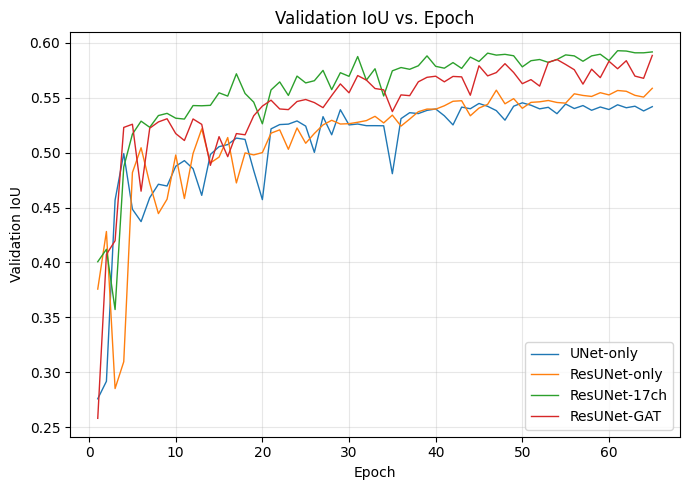

In [5]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt


def parse_training_log(log_path):
    pattern = re.compile(
        r"Epoch \[(\d+)/\d+\]\s*\|\s*Train Loss:\s*([0-9.]+)\s*\|\s*Val Loss:\s*([0-9.]+)\s+IoU:\s*([0-9.]+)",
        re.IGNORECASE,
    )

    epochs = []
    train_loss = []
    val_loss = []
    val_iou = []

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                epochs.append(int(match.group(1)))
                train_loss.append(float(match.group(2)))
                val_loss.append(float(match.group(3)))
                val_iou.append(float(match.group(4)))

    return {
        "epochs": epochs,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_iou": val_iou,
    }


base_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
log_files = {
    "UNet-only": "Unetonly.txt",
    "ResUNet-only": "resunetonly.txt",
    "ResUNet-17ch": "resunet_17ch.txt",
    "ResUNet-GAT": "resunet_gat.txt",
    
}

parsed_logs = {}
for label, filename in log_files.items():
    for base in base_candidates:
        path = base /"assects" / filename
        if path.exists():
            parsed_logs[label] = parse_training_log(path)
            break

if not parsed_logs:
    raise FileNotFoundError("Could not find any of the training log files in the current workspace.")

fig, axes = plt.subplots(1, 1, figsize=(7, 5), constrained_layout=True)

for label, data in parsed_logs.items():
    axes.plot(data["epochs"], data["val_iou"], label=label, linewidth=1)


axes.set_title("Validation IoU vs. Epoch")
axes.set_xlabel("Epoch")
axes.set_ylabel("Validation IoU")
axes.grid(True, alpha=0.3)
axes.legend()

plt.tight_layout()
plt.savefig("validation_iou.pdf", format="pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.savefig("validation_iou.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()

C:\Users\Aman\AppData\Local\Temp\ipykernel_7848\3191432035.py:72: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


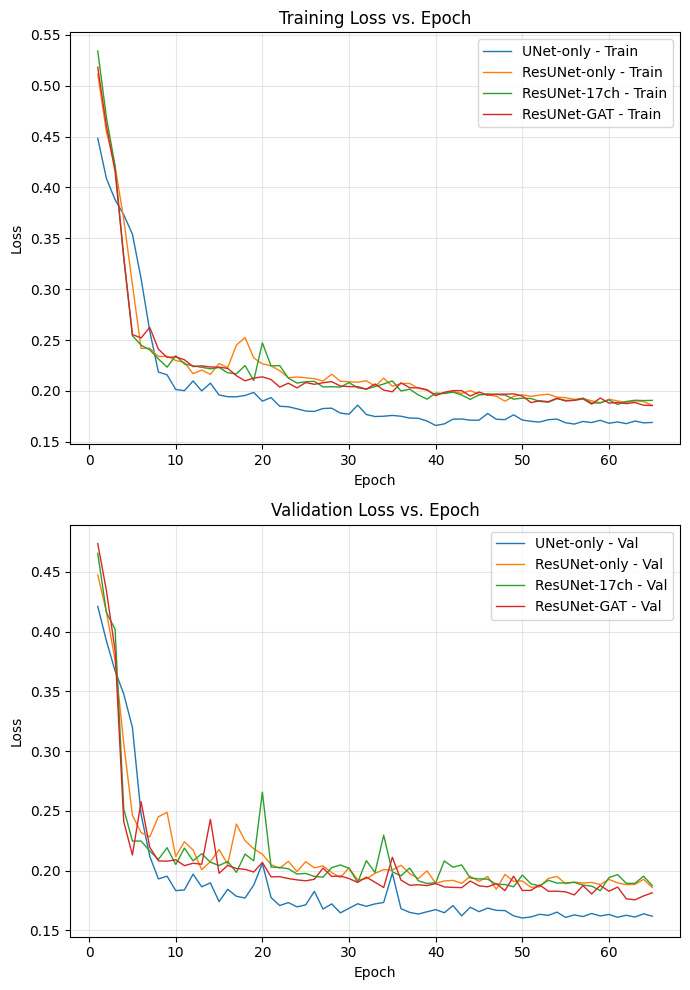

In [6]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt


def parse_training_log(log_path):
    pattern = re.compile(
        r"Epoch \[(\d+)/\d+\]\s*\|\s*Train Loss:\s*([0-9.]+)\s*\|\s*Val Loss:\s*([0-9.]+)\s+IoU:\s*([0-9.]+)",
        re.IGNORECASE,
    )

    epochs = []
    train_loss = []
    val_loss = []
    val_iou = []

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                epochs.append(int(match.group(1)))
                train_loss.append(float(match.group(2)))
                val_loss.append(float(match.group(3)))
                val_iou.append(float(match.group(4)))

    return {
        "epochs": epochs,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_iou": val_iou,
    }


base_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
log_files = {
    "UNet-only": "Unetonly.txt",
    "ResUNet-only": "resunetonly.txt",
    "ResUNet-17ch": "resunet_17ch.txt",
    "ResUNet-GAT": "resunet_gat.txt",
}

parsed_logs = {}
for label, filename in log_files.items():
    for base in base_candidates:
        path = base / "assects" / filename
        if path.exists():
            parsed_logs[label] = parse_training_log(path)
            break

if not parsed_logs:
    raise FileNotFoundError("Could not find any of the training log files in the current workspace.")

fig, axes = plt.subplots(2, 1, figsize=(7, 10), constrained_layout=True)

for label, data in parsed_logs.items():
    axes[0].plot(data["epochs"], data["train_loss"], label=f"{label} - Train", linewidth=1)
    axes[1].plot(data["epochs"], data["val_loss"], label=f"{label} - Val", linewidth=1)

axes[0].set_title("Training Loss vs. Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Validation Loss vs. Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("training_and_validation_loss.pdf", format="pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.savefig("training_and_validation_loss.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()

In [35]:
from pathlib import Path
print(Path.cwd())
print(list(Path.cwd().glob("**/*.txt")))

/content
[]
